# NYC Restaurant Inspections Data Analysis
---
## Research Question
How does restaurant health inspection risk vary across neighborhoods in New York City, and what does that variation suggest about the relationship between neighborhood conditions and food safety outcomes?

## Datasets
[New York City Restaurant Inspection Results](https://data.cityofnewyork.us/Health/DOHMH-New-York-City-Restaurant-Inspection-Results/43nn-pn8j/about_data)

[New York City Rodent Inspections](https://data.cityofnewyork.us/Health/Rodent-Inspection/p937-wjvj/about_data)

[New York City Income Dataset TO BE LOADED]

[New York City 311 Complaint Dataset](https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2020-to-Present/erm2-nwe9/about_data)

---

## Table of Contents

1.   Setup
2.   Data Loading
3.   Restaurant Inspection Data Analysis (Cleaning, Exploration, Visualization)
4.   Rodent Inspection Data Analysis (Cleaning, Exploration, Visualization)
5.   Socioeconomic Data Analysis (Cleaning, Exploration, Visualization)
6.   311 Complaint Data Analysis (Cleaning, Exploration, Visualization)
---


## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO

---

## Data Loading

In [ ]:
base_url = "https://data.cityofnewyork.us/resource/43nn-pn8j.csv"

params = {
    "$select": "camis,dba,boro,zipcode,cuisine_description,inspection_date,critical_flag,score,grade,latitude,longitude",
    "$where": "boro='Queens' AND inspection_date>'2023-01-01T00:00:00'",
    "$limit": 300000
}

response = requests.get(base_url, params=params)
inspections_df = pd.read_csv(StringIO(response.text))

(68264, 11)

In [13]:
base_url = "https://data.cityofnewyork.us/resource/p937-wjvj.csv"

params = {
    "$select": "inspection_type,zip_code,borough,inspection_date,result,latitude,longitude",
    "$where": "borough='Queens' AND inspection_date>'2023-01-01T00:00:00'",
    "$limit": 300000
}

response = requests.get(base_url, params=params)
rodents_df = pd.read_csv(StringIO(response.text))

In [ ]:
base_url = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv"

params = {
    "$select": "created_date,agency,complaint_type,descriptor,borough,latitude,longitude",
    "$where": "borough='QUEENS' AND created_date>'2023-01-01T00:00:00'",
    "$limit": 3000000
}

response = requests.get(base_url, params=params)
complaints_df = pd.read_csv(StringIO(response.text))

(2973737, 7)

---

## Restaraunt Inspection Data Analysis (Cleaning, Exploration, Visualization)

In [9]:
inspections_df.shape

(67998, 11)

In [22]:
inspections_df.columns

Index(['camis', 'dba', 'boro', 'zipcode', 'cuisine_description',
       'inspection_date', 'critical_flag', 'score', 'grade', 'latitude',
       'longitude'],
      dtype='str')

In [10]:
inspections_df.head()

,camis,dba,boro,zipcode,cuisine_description,inspection_date,critical_flag,score,grade,latitude,longitude
0,50143076,CHASE AD JFK,Queens,11430.0,Continental,2024-02-07T00:00:00.000,Critical,13.0,A,NaN,NaN
1,41503108,TULCINGO RESTAURANT,Queens,NaN,Mexican,2024-04-15T00:00:00.000,Critical,40.0,C,0.000000,0.000000
2,50107193,NUTRIPLATES,Queens,NaN,American,2026-06-24T00:00:00.000,Critical,12.0,A,0.000000,0.000000
3,50163616,RHYTHMS ON THE ROCK,Queens,11694.0,Caribbean,2025-08-22T00:00:00.000,Not Applicable,0.0,NaN,40.580732,-73.833954
4,41685800,OLMSTED CAFETERIA- KIOSK,Queens,NaN,American,2025-08-13T00:00:00.000,Not Critical,13.0,A,0.000000,0.000000


In [18]:
inspections_df.isna().sum()

camis                      0
dba                        0
boro                       0
zipcode                  516
cuisine_description        0
inspection_date            0
critical_flag              0
score                   3454
grade                  35264
latitude                 423
longitude                423
dtype: int64

### Key Metrics:

In [46]:
# Data Visualization Setup
sns.set_theme(style="whitegrid")
colors = sns.color_palette("Purples_d")

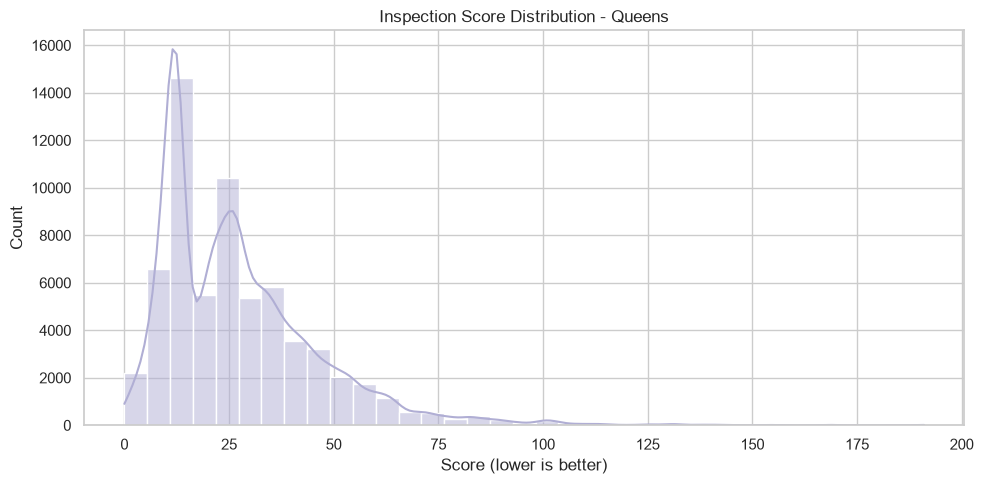

In [47]:
# Inspection Score Distribution - Queens
plt.figure(figsize=(10, 5))
sns.histplot(inspections_df['score'].dropna(), bins=35, color=colors[0], kde=True)
plt.title('Inspection Score Distribution - Queens')
plt.xlabel('Score (lower is better)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\chena\AppData\Local\Temp\ipykernel_35104\1875966845.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade_counts.index, y=grade_counts.values, palette="Purples_d")


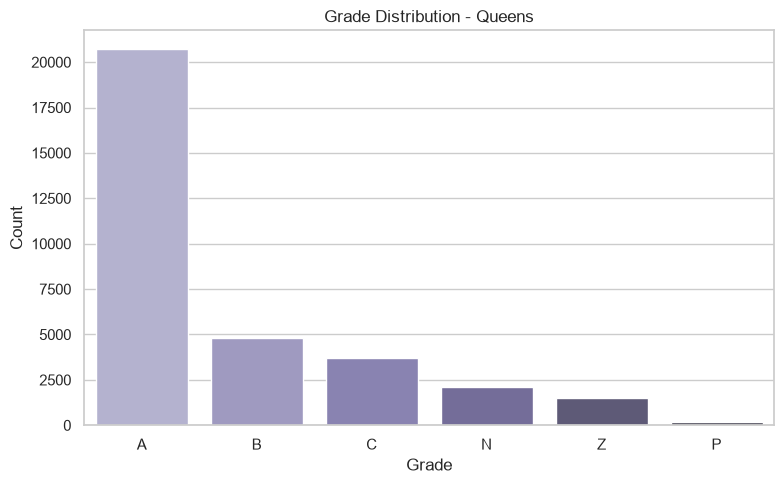

In [49]:
# Grade Distribution - Queens
grade_counts = inspections_df['grade'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=grade_counts.index, y=grade_counts.values, palette="Purples_d")
plt.title('Grade Distribution - Queens')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

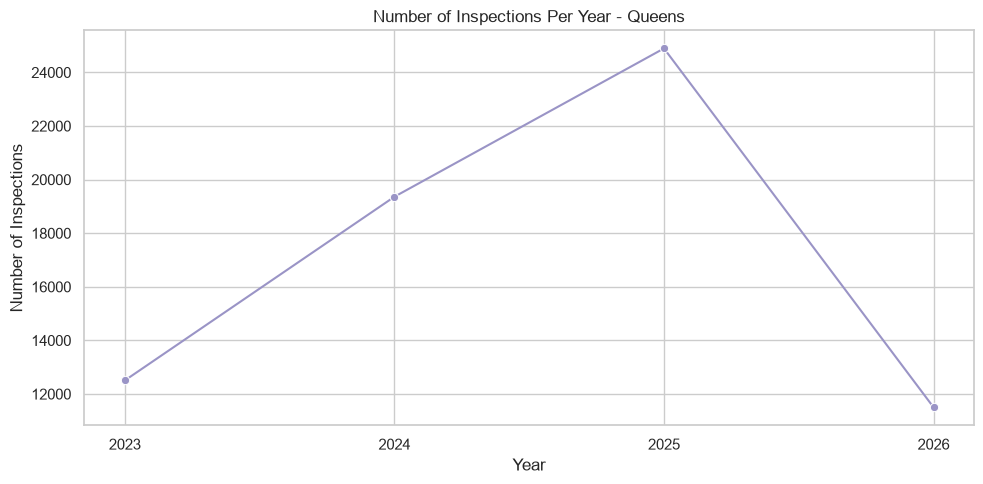

In [51]:
# Number of Inspections Per Year - Queens
inspections_df['year'] = pd.to_datetime(inspections_df['inspection_date']).dt.year
year_counts = inspections_df['year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color=colors[1])
plt.title('Number of Inspections Per Year - Queens')
plt.xlabel('Year')
plt.ylabel('Number of Inspections')
plt.xticks(year_counts.index, year_counts.index.astype(int))
plt.tight_layout()
plt.show()

C:\Users\chena\AppData\Local\Temp\ipykernel_35104\467750586.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="Purples_d")


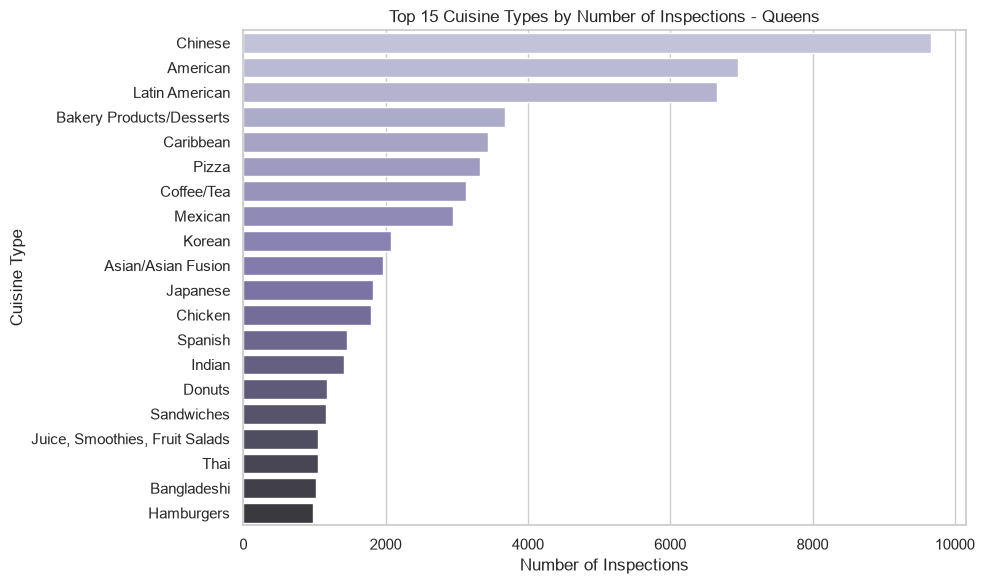

In [ ]:
# Top 20 Cuisine Types by Number of Inspections - Queens
top_cuisines = inspections_df['cuisine_description'].value_counts().head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="Purples_d")
plt.title('Top 15 Cuisine Types by Number of Inspections - Queens')
plt.xlabel('Number of Inspections')
plt.ylabel('Cuisine Type')
plt.tight_layout()
plt.show()